**Building a CNN Model for Image Classification**

In [ ]:
# Importing libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from tensorflow.keras import layers,models
from tensorflow import keras


In [36]:
#  Load the dataset and explore its structure (number of classes, sample images, image sizes).
traindata=tf.keras.utils.image_dataset_from_directory(
    "../Dataset/data/seg_train",
    # Resize all images to a common size (e.g., 150×150).
    image_size=(150,150),
    batch_size=32,
    validation_split=0.2,
    color_mode="grayscale",
    subset="training",
    seed=123
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [37]:
print("\nTrain dataset Class names :",traindata.class_names)


Train dataset Class names : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [38]:
valdata=tf.keras.utils.image_dataset_from_directory(
    "../Dataset/data/seg_train",
    # Resize all images to a common size (e.g., 150×150).
    image_size=(150,150),
    batch_size=32,
    validation_split=0.2,
    color_mode="grayscale",
    subset="validation",
    seed=123
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [39]:
print("\nEvaluation dataset Class names :",valdata.class_names)


Evaluation dataset Class names : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [40]:
normalization=layers.Rescaling(1./255)

In [41]:
traindata = traindata.map(
    lambda x, y: (normalization(x), y)
)

In [42]:
valdata = valdata.map(
    lambda x, y: (normalization(x), y)
)

In [44]:
# Apply data augmentation (rotation, flip, zoom, shift, etc.) to improve generalization.
dataAugmentation=keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.2),   
])


**CNN Model Development**


In [ ]:
#  Convolutional Neural Network (CNN)

model=models.Sequential([
    layers.Input(shape=(150,150,1)),
    dataAugmentation,
    layers.Conv2D(filters=32,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(filters=64,
        kernel_size=(3,3),
        activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    
   
    layers.Dense(64,activation="relu"),
   

    layers.Dense(6,activation="softmax")

])

In [46]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,432,006 (9.28 MB)

 Trainable params: 2,432,006 (9.28 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
# Use early stopping and model checkpointing if necessary.

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
# Model training

history=model.fit(
    traindata,
    validation_data=valdata,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

In [50]:
loss,accuracy=model.evaluate(valdata)

88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8136 - loss: 0.5355


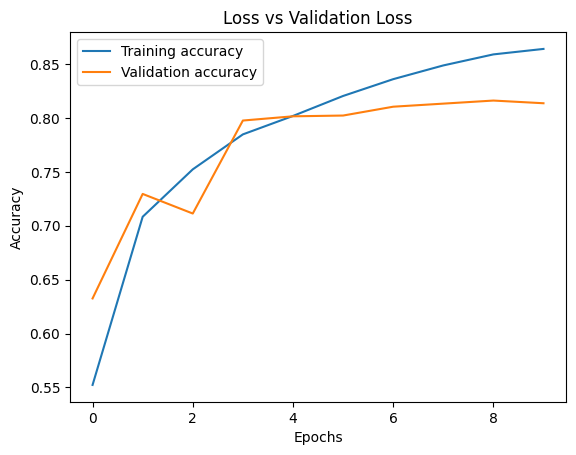

In [51]:
# Plot training vs. validation loss curves.
plt.plot(history.history["accuracy"],label="Training accuracy")
plt.plot(history.history["val_accuracy"],label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Loss vs Validation Loss")
plt.legend()
plt.show()
plt.show()

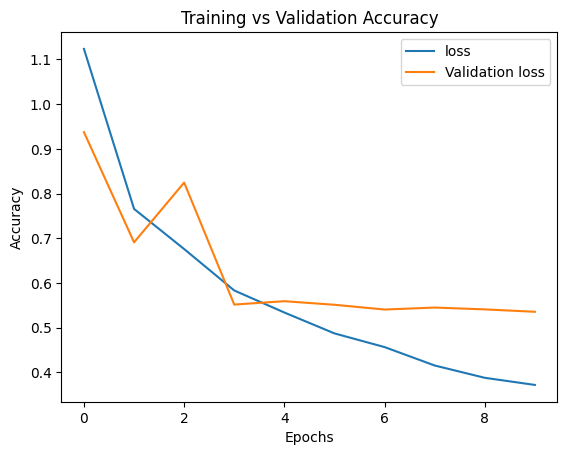

In [52]:
#  Plot training vs. validation accuracy curves
plt.plot(history.history["loss"],label="loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()
plt.show()

**Model Evaluation and Interpretation**

In [108]:
testdata=keras.utils.image_dataset_from_directory(
    "../Dataset/data/seg_test",
    image_size=(150,150),
    batch_size=32,
    color_mode="grayscale",
    seed=123,
)


Found 3000 files belonging to 6 classes.


In [109]:
class_names = testdata.class_names

In [ ]:
testdata = testdata.map(
    lambda x, y: (normalization(x), y)
)

In [ ]:
# Evaluate the model on the test set and report performance metrics
y_pred=[]
y_true=[]
for image,labels in testdata:
    pred=model.predict(image)
    y_pred.extend(labels.numpy())
    y_true.extend(np.argmax(pred,axis=1))


In [ ]:
# Accuracy

print("Accuracy score : ",accuracy_score(y_true,y_pred))

Accuracy score :  0.8106666666666666


In [ ]:
# Precision, Recall, F1-score per class

print("Classification report\n\n",classification_report(y_true,y_pred))

Classification report

               precision    recall  f1-score   support

           0       0.78      0.80      0.79       425
           1       0.95      0.96      0.95       465
           2       0.77      0.74      0.75       571
           3       0.76      0.74      0.75       533
           4       0.73      0.89      0.80       414
           5       0.90      0.76      0.83       592

    accuracy                           0.81      3000
   macro avg       0.81      0.82      0.81      3000
weighted avg       0.82      0.81      0.81      3000



In [ ]:
# Confusion Matrix

print("Confusion matrix \n\n",confusion_matrix(y_true,y_pred))

Confusion matrix 

 [[341   4  15  10  17  38]
 [  5 448   4   3   2   3]
 [  6   1 424  84  53   3]
 [  1   4  81 397  48   2]
 [  2   1  14  24 370   3]
 [ 82  16  15   7  20 452]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


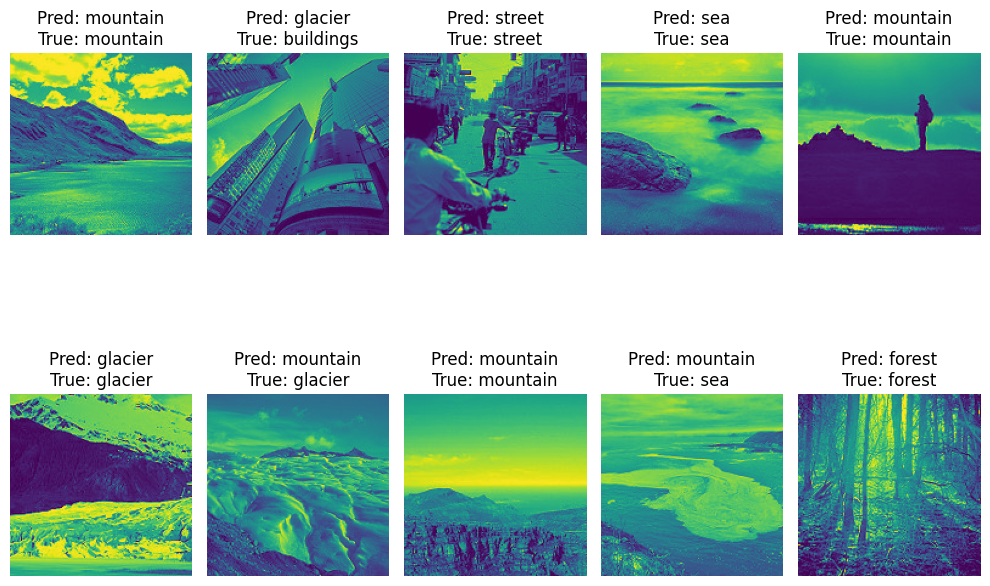

In [ ]:
# Visualize predictions for at least 10 random test images with predicted vs. actual labels.

normal=layers.Rescaling(255)
testdata=testdata.map(
    lambda x,y:(normal(x))
)
for images, labels in testdata.take(1):

    predictions = model.predict(images)
    y_pred = np.argmax(predictions, axis=1)

    plt.figure(figsize=(10,8))

    for i in range(10):

        plt.subplot(2,5,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            f"Pred: {class_names[y_pred[i]]}\n"
            f"True: {class_names[labels[i]]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()